In [1]:
import csv
import nibabel as nib
import matplotlib.pyplot as plt
import random
import torch
import os
import numpy as np
from model1 import CNN_3D,NiiDataset,MultiModalTransformer,NeuralNet,TransEModel,KGMultiModalTransformer
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import nibabel as nib
import shutil
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import math
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import pandas as pd

In [2]:
path_existence = []
data_prodromal=[]
data_swedd=[]
data_control=[]
data_PD = []
count_control = 0
count_PD = 0
count_swedd = 0
count_prodromal = 0
with open('PD1.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader)  
    for row in csv_reader:
        path = 'PD/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_PD=count_PD+1
            data_PD.append(row)
            
with open('control.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'Control/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_control=count_control+1
            data_control.append(row)
            
with open('swedd.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'SWEDD/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_swedd=count_swedd+1
            data_swedd.append(row)

with open('prodromal.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'Prodromal/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_prodromal=count_prodromal+1
            data_prodromal.append(row)
print(count_PD) #44
print(count_control) #247
print(count_swedd) #106
print(count_prodromal)

125
132
72
80


In [3]:
PD_arrays=[]
replace_dict = {'F': '0','M':'1','Normal':'0','Slight':'1','Mild':'2','Moderate':'3','Severe':'4','T1-anatomical':'1','Processed':'1', 
               'BL':'0','V04':'1','V06':'2','V06':'3','V08':'4','V10':'5','NiFTI':'1','':'0','No':'0','Yes':'1','Stage 1':'1','Stage 2':'2','Stage 3':'3','Stage 4':'4'
               ,'On':'1','Off':'0','Stage 0':'0'}
for i in data_PD:
    j= i[21:]
    j= [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    PD_array = np.array(num_list)
    PD_arrays.append(PD_array)
PD_array = np.vstack(PD_arrays)

In [4]:
control_arrays = []
for i in data_control:
    j = i[21:]
    j = [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    control_array = np.array(num_list)
    control_arrays.append(control_array)
control_array = np.vstack(control_arrays)

In [5]:
swedd_arrays = []
for i in data_swedd:
    j = i[21:]
    j = [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    swedd_array = np.array(num_list)
    swedd_arrays.append(swedd_array)
swedd_array = np.vstack(swedd_arrays)

In [6]:
prodromal_arrays = []
for i in data_prodromal:
    j = i[21:]
    j = [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    prodromal_array = np.array(num_list)
    prodromal_arrays.append(prodromal_array)
prodromal_array = np.vstack(prodromal_arrays)

In [7]:
#加权算值
def weighted_sum(tensor):
    weights = [0.1, 0.3, 0.5 , 0.7]
    weight_tensor = torch.tensor(weights, dtype=tensor.dtype, device=tensor.device)
    weighted_sum_result = torch.sum(tensor * weight_tensor, dim=1, keepdim=True)
    return weighted_sum_result

In [8]:
pd_tensor = torch.from_numpy(PD_array).float()
control_tensor = torch.from_numpy(control_array).float()
swedd_tensor = torch.from_numpy(swedd_array).float()
prodromal_tensor = torch.from_numpy(prodromal_array).float()

pd_labels = torch.zeros(pd_tensor.shape[0], dtype=torch.long)
control_labels = torch.ones(control_tensor.shape[0], dtype=torch.long)
swedd_labels = torch.full((swedd_tensor.shape[0],), 3, dtype=torch.long)
prodromal_labels = torch.full((prodromal_tensor.shape[0],), 2, dtype=torch.long)

X = torch.cat([pd_tensor, control_tensor, swedd_tensor,prodromal_tensor], dim=0)
y = torch.cat([pd_labels , control_labels  ,swedd_labels, prodromal_labels], dim=0)

dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
model = NeuralNet(embedding=64)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 50
for epoch in range(num_epochs):
    for inputs, labels in dataloader:
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')
        
with torch.no_grad():
    pd_tensor = model(pd_tensor)
    control_tensor = model(control_tensor)
    swedd_tensor = model(swedd_tensor)
    prodromal_tensor = model(prodromal_tensor)
    
pd_tensor = weighted_sum(pd_tensor)
control_tensor = weighted_sum(control_tensor)
swedd_tensor = weighted_sum(swedd_tensor)
prodromal_tensor = weighted_sum(prodromal_tensor)

Epoch [10/50], Loss: 0.9098
Epoch [20/50], Loss: 0.7179
Epoch [30/50], Loss: 0.5551
Epoch [40/50], Loss: 0.5010
Epoch [50/50], Loss: 0.6377


In [9]:
# 数据处理函数
def preprocess_data(data, replace_dict):
    processed_data = []
    for row in data:
        row = [replace_dict.get(item, item) for item in row]
        row = [float(item) if item.replace('.', '', 1).isdigit() else item for item in row]
        processed_data.append(row[4:22])
    return np.array(processed_data)

In [10]:
# 编码类别型变量
def encode_categorical(data, categorical_indices):
    encoded_data = data.copy()
    for idx in categorical_indices:
        le = LabelEncoder()
        encoded_data[:, idx] = le.fit_transform(encoded_data[:, idx])
    return encoded_data.astype(float)

In [11]:
pd_data = preprocess_data(data_PD, replace_dict)
control_data = preprocess_data(data_control, replace_dict)
swedd_data = preprocess_data(data_swedd, replace_dict)
prodromal_data = preprocess_data(data_prodromal, replace_dict)

categorical_indices = [2, 3, 4, 5]  # gender, education, hispanic, race, apoe
pd_EHR = encode_categorical(pd_data, categorical_indices)
control_EHR = encode_categorical(control_data, categorical_indices)
swedd_EHR = encode_categorical(swedd_data, categorical_indices)
prodromal_EHR = encode_categorical(prodromal_data, categorical_indices)

pd_EHR = torch.from_numpy(pd_EHR).float()
control_EHR = torch.from_numpy(control_EHR).float()
swedd_EHR = torch.from_numpy(swedd_EHR).float()
prodromal_EHR = torch.from_numpy(prodromal_EHR).float()

linear_layer = nn.Linear(18, 16)
control_EHR = linear_layer(control_EHR)
pd_EHR = linear_layer(pd_EHR)
swedd_EHR = linear_layer(swedd_EHR)
prodromal_EHR = linear_layer(prodromal_EHR)

linear_layer = nn.Linear(16, 1)
control_EHR = linear_layer(control_EHR)
pd_EHR = linear_layer(pd_EHR)
swedd_EHR = linear_layer(swedd_EHR)
prodromal_EHR = linear_layer(prodromal_EHR)

print('pd.EHR--->', pd_EHR.shape)
print('control.EHR--->', control_EHR.shape)
print('swedd.EHR--->', swedd_EHR.shape)
print('prodromal.EHR--->', prodromal_EHR.shape)

pd.EHR---> torch.Size([125, 1])
control.EHR---> torch.Size([132, 1])
swedd.EHR---> torch.Size([72, 1])
prodromal.EHR---> torch.Size([80, 1])


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [13]:
def center_crop_3d(tensor, size):
    depth, height, width = tensor.shape
    target_depth, target_height, target_width = size

    start_depth = (depth - target_depth) // 2
    start_height = (height - target_height) // 2
    start_width = (width - target_width) // 2

    end_depth = start_depth + target_depth
    end_height = start_height + target_height
    end_width = start_width + target_width

    return tensor[start_depth:end_depth, start_height:end_height, start_width:end_width]


In [14]:
import os
import torch
from torch.utils.data import DataLoader, Dataset
import nibabel as nib

# 你的 NiiDataset，务必用这版
class NiiDataset(Dataset):
    def __init__(self, file_list_or_folder):
        if isinstance(file_list_or_folder, list):
            self.file_list = file_list_or_folder
        elif isinstance(file_list_or_folder, str):
            folder_path = file_list_or_folder
            self.file_list = [os.path.join(folder_path, filename)
                              for filename in os.listdir(folder_path)
                              if filename.endswith('.nii') or filename.endswith('.nii.gz')]
        else:
            raise ValueError("参数应为list或str")
    def __len__(self):
        return len(self.file_list)
    def __getitem__(self, idx):
        file_path = self.file_list[idx]
        img = nib.load(file_path)
        img_data = img.get_fdata()
        img_tensor = torch.from_numpy(img_data).float()
        cropped_tensor = center_crop_3d(img_tensor, (64, 64, 64))   # 你的裁剪函数
        input_tensor = cropped_tensor.unsqueeze(0)
        return input_tensor

# 1. 严格用csv顺序生成影像路径
pd_img_paths = [os.path.join('PD', row[1]) for row in data_PD if os.path.exists(os.path.join('PD', row[1]))]
control_img_paths = [os.path.join('Control', row[1]) for row in data_control if os.path.exists(os.path.join('Control', row[1]))]
swedd_img_paths = [os.path.join('SWEDD', row[1]) for row in data_swedd if os.path.exists(os.path.join('SWEDD', row[1]))]
prodromal_img_paths = [os.path.join('Prodromal', row[1]) for row in data_prodromal if os.path.exists(os.path.join('Prodromal', row[1]))]

print(f'PD影像数量: {len(pd_img_paths)}')
print(f'Control影像数量: {len(control_img_paths)}')
print(f'SWEDD影像数量: {len(swedd_img_paths)}')
print(f'Prodromal影像数量: {len(prodromal_img_paths)}')

batch_size = 16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
nii = CNN_3D(num_class=1)
nii = nii.to(device)

# 2. 用于影像特征提取
# PD组
dataset = NiiDataset(pd_img_paths)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
PD_output = torch.cat(all_outputs, dim=0)
print('PD nii shape--->', PD_output.shape)

# Control组
dataset = NiiDataset(control_img_paths)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
control_output = torch.cat(all_outputs, dim=0)
print('control nii shape--->', control_output.shape)

# Prodromal组
dataset = NiiDataset(prodromal_img_paths)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
prodromal_output = torch.cat(all_outputs, dim=0)
print('prodromal nii shape--->', prodromal_output.shape)

# SWEDD组
dataset = NiiDataset(swedd_img_paths)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
swedd_output = torch.cat(all_outputs, dim=0)
print('swedd nii shape--->', swedd_output.shape)


PD影像数量: 125
Control影像数量: 132
SWEDD影像数量: 72
Prodromal影像数量: 80
PD nii shape---> torch.Size([125, 1])
control nii shape---> torch.Size([132, 1])
prodromal nii shape---> torch.Size([80, 1])
swedd nii shape---> torch.Size([72, 1])


In [15]:
# 定义文件夹路径
nii_folders = {
    'Control': 'Control',
    'PD': 'PD',  
    'Prodromal': 'Prodromal',
    'SWEDD':'SWEDD'
}

# 读取 CSV 文件
pd_df = pd.read_csv('PD1.csv')
control_df = pd.read_csv('control.csv')
prodromal_df = pd.read_csv('prodromal.csv')
swedd_df=pd.read_csv('swedd.csv')


entities = set()
for df in [pd_df, control_df, prodromal_df,swedd_df]:
    for col in df.columns[8:]:
        entities.update(df[col].astype(str).unique())

entities.update(df['Subject'].astype(str).unique())

# 读取 entity2id 映射
entity2id = {}
with open('entity2id.txt', 'r') as f:
    for line in f:
        entity, id = line.strip().split('\t')
        entity2id[entity] = id  

# 初始化实体嵌入
entity_embeddings = torch.randn(len(entity2id), 32)

# 定义 TransE 模型类
class TransEextract:
    def __init__(self, entity_embeddings, entity2id):
        self.entity_embeddings = entity_embeddings
        self.entity2id = entity2id
        self.id_to_index = {id: idx for idx, id in enumerate(sorted(entity2id.values()))}

    def get_entity_embedding(self, entity):
        if entity in self.entity2id:
            entity_id = self.entity2id[entity]
            entity_index = self.id_to_index[entity_id]
            return self.entity_embeddings[entity_index]
        else:
            raise ValueError(f"Entity {entity} not found in entity2id mapping")

# 初始化模型
model = TransEextract(entity_embeddings, entity2id)

# 获取嵌入向量
def get_embeddings(df, model, nii_folder):
    embeddings_list = []
    skipped_rows = 0
    for index, row in df.iterrows():
        # 检查 .nii 文件是否存在
        nii_file = row.iloc[1]
        nii_path = os.path.join(nii_folder, nii_file)
        if not os.path.exists(nii_path):
            skipped_rows += 1
            continue
        row_embeddings = []
        for col in df.columns[7:]:
            entity = str(row[col])
            if entity != '0' and entity in model.entity2id:
                row_embeddings.append(model.get_entity_embedding(entity))
        # 将路径和文件名也作为实体
        filename = str(row['Subject'])
        if filename in model.entity2id:
            row_embeddings.append(model.get_entity_embedding(filename))

        
        if row_embeddings:
            mean_embedding = torch.stack(row_embeddings).mean(dim=0)
            embeddings_list.append(mean_embedding)

    
    if not embeddings_list:
        return torch.empty((0, 32))
    return torch.stack(embeddings_list)

# 获取嵌入向量
pd_transe = get_embeddings(pd_df, model, nii_folders['PD'])
control_transe = get_embeddings(control_df, model, nii_folders['Control'])
prodromal_transe = get_embeddings(prodromal_df, model, nii_folders['Prodromal'])
swedd_transe = get_embeddings(swedd_df, model, nii_folders['SWEDD'])

print(pd_transe.shape)
print(control_transe.shape)
print(prodromal_transe.shape)
print(swedd_transe.shape)


torch.Size([125, 32])
torch.Size([132, 32])
torch.Size([80, 32])
torch.Size([72, 32])


In [16]:
transe_embed_dim = 32

X_pd = torch.cat([pd_EHR, PD_output.cpu(), pd_tensor,pd_transe], dim=1)
X_control = torch.cat([control_EHR, control_output.cpu(), control_tensor,control_transe], dim=1)
X_swedd = torch.cat([swedd_EHR, swedd_output.cpu(), swedd_tensor,swedd_transe], dim=1)
X_prodromal = torch.cat([prodromal_EHR, prodromal_output.cpu(), prodromal_tensor,prodromal_transe], dim=1)

y_pd = torch.ones(len(X_pd)) * 0  # PD 类别标签为 0
y_control = torch.ones(len(X_control)) * 1  # Control 类别标签为 1
y_prodromal = torch.ones(len(X_prodromal)) * 3  # Prodomal 类别标签为 2
y_swedd = torch.ones(len(X_swedd)) * 2  # Swedd 类别标签为 3

# 拼接特征和标签
X = torch.cat([X_pd[:120], X_control, X_prodromal, X_swedd], dim=0).float()
y = torch.cat([y_pd[:120], y_control, y_prodromal, y_swedd], dim=0).float()

features = X[:, :-transe_embed_dim]  
transe_embeddings = X[:, -transe_embed_dim:]  



X_train, X_test, y_train, y_test, transe_train, transe_test = train_test_split(
    features.detach().numpy(), y.numpy(), transe_embeddings.detach().numpy(),
    test_size=0.20,
    stratify=y.numpy(),
    random_state=32
)
X_train, X_val, y_train, y_val, transe_train, transe_val = train_test_split(
    X_train, y_train, transe_train,
    test_size=0.20,
    stratify=y_train,
    random_state=30
)


X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)  # Use LongTensor for classification labels
transe_train_tensor = torch.FloatTensor(transe_train).to(device)

X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.LongTensor(y_val).to(device)
transe_val_tensor = torch.FloatTensor(transe_val).to(device)

X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)
transe_test_tensor = torch.FloatTensor(transe_test).to(device)


train_dataset = TensorDataset(X_train_tensor, transe_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, transe_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, transe_test_tensor, y_test_tensor)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [17]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    
    for inputs, transe_embed, labels in loader:
        inputs, transe_embed, labels = inputs.to(device), transe_embed.to(device), labels.to(device)
        labels = labels.long()
        
        optimizer.zero_grad()
        outputs = model(inputs, transe_embed)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

        probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
        preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds)

    # Convert lists to numpy arrays for easier manipulation
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    train_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    train_f1 = f1_score(all_labels, all_preds, average='macro')
    train_recall = recall_score(all_labels, all_preds, average='macro')
    train_precision = precision_score(all_labels, all_preds, average='macro')

    avg_loss = total_loss / len(loader)
    return avg_loss, train_auc, train_f1, train_recall, train_precision

def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for inputs, transe_embed, labels in loader:
            inputs, transe_embed, labels = inputs.to(device), transe_embed.to(device), labels.to(device)
            labels = labels.long()
            
            outputs = model(inputs, transe_embed)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
            preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds)
    
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    # 计算指标
    val_auc = roc_auc_score(all_labels, all_probs, multi_class='ovo')
    val_f1 = f1_score(all_labels, all_preds, average='macro')
    val_recall = recall_score(all_labels, all_preds, average='macro')
    val_precision = precision_score(all_labels, all_preds, average='macro')
    
    # 计算平均损失
    avg_loss = total_loss / len(loader)
    return avg_loss, val_auc, val_f1, val_recall, val_precision


In [18]:
embed_dim = 32
transe_embed_dim = 32
num_epochs = 200
batch_size = 32
learning_rate = 1e-5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weight_decay = 1e-3

transe_model = TransEModel(num_entities=381, num_relations=2, embed_dim=200)
transe_model.load_state_dict(torch.load('transe.ckpt', map_location=torch.device('cpu')))
transe_model.eval()


model = KGMultiModalTransformer(embed_dim=embed_dim, transe_embed_dim=transe_embed_dim).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate,weight_decay=weight_decay)

train_losses = []
train_aucs = []
train_f1s = []
train_recalls = []
train_precisions = []
test_losses = []
test_aucs = []
test_f1s = []
test_recalls = []
test_precisions = []

for epoch in range(num_epochs):
    train_loss, train_auc, train_f1, train_recall, train_precision = train_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_auc, test_f1, test_recall, test_precision = validate_epoch(model, test_loader, criterion, device)
    
    train_losses.append(train_loss)
    train_aucs.append(train_auc)
    train_f1s.append(train_f1)
    train_recalls.append(train_recall)
    train_precisions.append(train_precision)
    
    test_losses.append(test_loss)
    test_aucs.append(test_auc)
    test_f1s.append(test_f1)
    test_recalls.append(test_recall)
    test_precisions.append(test_precision)
    
    print(f"Epoch {epoch + 1}/{num_epochs}, "
          f"Train Loss: {train_loss:.4f}, Train AUC: {train_auc:.4f}  "   
          f"test Loss: {test_loss:.4f}, test AUC: {test_auc:.4f}")

Epoch 1/200, Train Loss: 1.4608, Train AUC: 0.5567  test Loss: 1.3708, test AUC: 0.5956
Epoch 2/200, Train Loss: 1.4195, Train AUC: 0.5632  test Loss: 1.3701, test AUC: 0.5925
Epoch 3/200, Train Loss: 1.4023, Train AUC: 0.5620  test Loss: 1.3701, test AUC: 0.5976
Epoch 4/200, Train Loss: 1.4163, Train AUC: 0.5581  test Loss: 1.3671, test AUC: 0.6031
Epoch 5/200, Train Loss: 1.4116, Train AUC: 0.5369  test Loss: 1.3737, test AUC: 0.6012
Epoch 6/200, Train Loss: 1.3810, Train AUC: 0.5730  test Loss: 1.3760, test AUC: 0.6018
Epoch 7/200, Train Loss: 1.4255, Train AUC: 0.5421  test Loss: 1.3767, test AUC: 0.6048
Epoch 8/200, Train Loss: 1.4151, Train AUC: 0.5501  test Loss: 1.3734, test AUC: 0.6060
Epoch 9/200, Train Loss: 1.4286, Train AUC: 0.5535  test Loss: 1.3680, test AUC: 0.6165
Epoch 10/200, Train Loss: 1.4415, Train AUC: 0.5407  test Loss: 1.3676, test AUC: 0.6125
Epoch 11/200, Train Loss: 1.4009, Train AUC: 0.5883  test Loss: 1.3644, test AUC: 0.6174
Epoch 12/200, Train Loss: 1.37

In [19]:
model.eval()
all_probs = []
all_labels = []
with torch.no_grad():
    for inputs, transe_embed, labels in val_loader:
        inputs, transe_embed, labels = inputs.to(device), transe_embed.to(device), labels.to(device)
        outputs = model(inputs, transe_embed)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())

preds = np.argmax(all_probs, axis=1)
accuracy = accuracy_score(all_labels, preds)
precision = precision_score(all_labels, preds, average='macro')
recall = recall_score(all_labels, preds, average='macro')
f1 = f1_score(all_labels, preds, average='macro')
auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')

print("\n=== Final Validation Metrics ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")


=== Final Validation Metrics ===
Accuracy:  0.5692
Precision: 0.5254
Recall:    0.4975
F1 Score:  0.4804
AUC-ROC:   0.7491


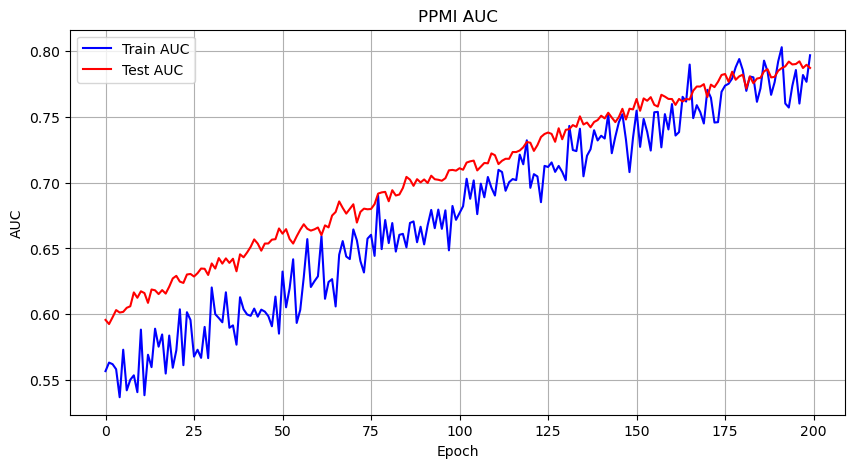

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_aucs)), train_aucs, label="Train AUC", color="blue")
plt.plot(range(len(test_aucs)), test_aucs, label="Test AUC", color="red")
plt.title("PPMI AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.show()

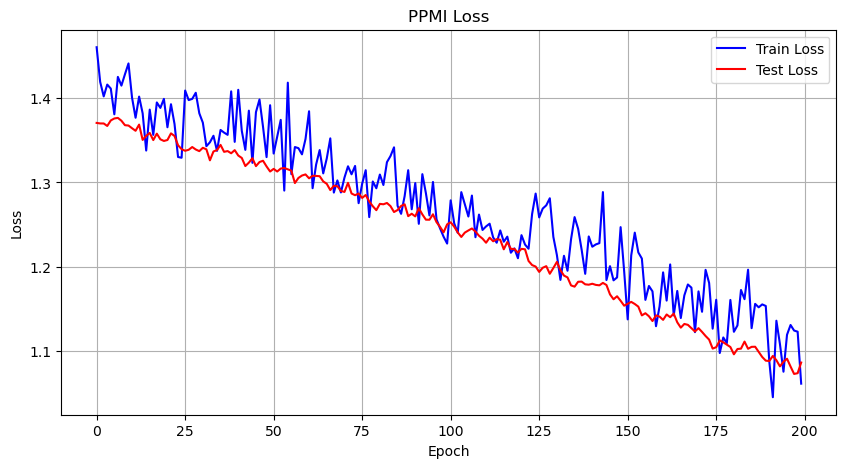

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_losses)), train_losses, label="Train Loss", color="blue")
plt.plot(range(len(test_losses)), test_losses, label="Test Loss", color="red")
plt.title("PPMI Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()